In [1]:
#MNIST Dataset

import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

training_dataset = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor()
)
test_data = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 507kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.28MB/s]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
train_loader = torch.utils.data.DataLoader(training_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=128, shuffle=True)


In [3]:
import os
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [5]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [6]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [7]:
#hyper_parameters

learning_rate = 1e-4
epochs = 10
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [8]:
def train_loop(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset)
  model.train()
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    pred = model(X)
    loss = loss_fn(pred, y)
    #backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step() # weight update

    if batch % 100 == 0:
      loss = loss.item()
      current = batch * len(X)
      print(f"loss: {loss:>7f} [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  test_loss, correct = 0, 0

  model.eval()
  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)
      pred = model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()

  test_loss /= num_batches
  correct /= size
  print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, avg loss: {test_loss:>8f} \n")

In [9]:
for e in range(epochs):
  print(f"Epoch {e+1}/{epochs}")
  train_loop(train_loader, model, loss_fn, optimizer)
  test_loop(test_loader, model, loss_fn)

print("Done!")

Epoch 1/10
loss: 2.304590 [    0/60000]
loss: 0.737417 [12800/60000]
loss: 0.482372 [25600/60000]
loss: 0.312903 [38400/60000]
loss: 0.302005 [51200/60000]
Test Error: 
 Accuracy: 91.6%, avg loss: 0.292371 

Epoch 2/10
loss: 0.317361 [    0/60000]
loss: 0.271877 [12800/60000]
loss: 0.259132 [25600/60000]
loss: 0.178660 [38400/60000]
loss: 0.244147 [51200/60000]
Test Error: 
 Accuracy: 93.2%, avg loss: 0.234072 

Epoch 3/10
loss: 0.228934 [    0/60000]
loss: 0.105097 [12800/60000]
loss: 0.184069 [25600/60000]
loss: 0.153381 [38400/60000]
loss: 0.225714 [51200/60000]
Test Error: 
 Accuracy: 94.6%, avg loss: 0.185255 

Epoch 4/10
loss: 0.226790 [    0/60000]
loss: 0.204875 [12800/60000]
loss: 0.186563 [25600/60000]
loss: 0.157902 [38400/60000]
loss: 0.128405 [51200/60000]
Test Error: 
 Accuracy: 95.4%, avg loss: 0.157435 

Epoch 5/10
loss: 0.200518 [    0/60000]
loss: 0.076260 [12800/60000]
loss: 0.188468 [25600/60000]
loss: 0.215645 [38400/60000]
loss: 0.132190 [51200/60000]
Test Error: 

In [10]:
torch.save(model, "model.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


In [11]:
model2 = NeuralNetwork().to(device)
model2 = torch.load("model.pth", weights_only = False)

In [12]:
test_loop(train_loader, model2, loss_fn)

Test Error: 
 Accuracy: 98.1%, avg loss: 0.066089 



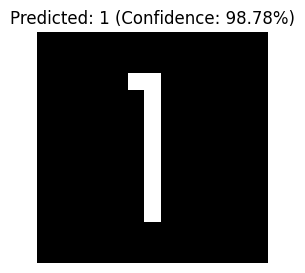

Model predicted: 1 with 98.78% confidence.
Probabilities for each digit:
  Digit 0: 0.0000
  Digit 1: 0.9878
  Digit 2: 0.0015
  Digit 3: 0.0027
  Digit 4: 0.0002
  Digit 5: 0.0003
  Digit 6: 0.0002
  Digit 7: 0.0016
  Digit 8: 0.0057
  Digit 9: 0.0002


In [ ]:
import numpy as np
from PIL import Image
import torchvision.transforms as transforms

# dummy NumPy array image of 1
dummy_image_np = np.zeros((28, 28), dtype=np.float32)
dummy_image_np[5:23, 13:15] = 1.0
dummy_image_np[5:7, 11:15] = 1.0

user_image_pil = Image.fromarray((dummy_image_np * 255).astype(np.uint8))

preprocess = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

input_tensor = preprocess(user_image_pil)

input_batch = input_tensor.unsqueeze(0)
input_batch = input_batch.to(device)

model.eval()
with torch.no_grad():
    output = model(input_batch)

probabilities = torch.nn.functional.softmax(output, dim=1)
predicted_class = torch.argmax(probabilities, dim=1).item()
confidence = probabilities[0, predicted_class].item() * 100

# Display input image and prediction
plt.figure(figsize=(3, 3))
plt.imshow(user_image_pil, cmap='gray')
plt.title(f"Predicted: {predicted_class} (Confidence: {confidence:.2f}%)")
plt.axis('off')
plt.show()

print(f"Model predicted: {predicted_class} with {confidence:.2f}% confidence.")
print("Probabilities for each digit:")
for i, prob in enumerate(probabilities[0]):
    print(f"  Digit {i}: {prob.item():.4f}")